# Milestone 1 — Baseline Image Captioning Pipeline

This notebook demonstrates the end-to-end Milestone 1 pipeline:
1. **Dataset** — Load and preprocess COCO Captions (Karpathy split, 2500 pairs)
2. **Image Embeddings** — Encode images using CLIP ViT-B/32 → 512-dim vectors
3. **Caption Tokenization** — Tokenize captions with GPT-2 BPE tokenizer
4. **Sample Test Runs** — Process 5 image-caption pairs and visualize results

**Dataset:** [`yerevann/coco-karpathy`](https://huggingface.co/datasets/yerevann/coco-karpathy)  
**Models:** CLIP ViT-B/32 (image encoder), GPT-2 tokenizer (caption tokenizer)  
**GitHub:** [heisenberg1804/image-captioning-with-CLIP-and-GPT-2](https://github.com/heisenberg1804/image-captioning-with-CLIP-and-GPT-2)

---
## 0. Install Dependencies

In [1]:
!pip install -q torch torchvision transformers datasets Pillow matplotlib tqdm ftfy regex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [2]:
import os
import re
import io
import random
import urllib.request

import torch
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from transformers import CLIPModel, CLIPProcessor, GPT2Tokenizer
from tqdm.auto import tqdm

# Device setup
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple MPS")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

# Config
DATASET_NAME = "yerevann/coco-karpathy"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
GPT2_MODEL_NAME = "gpt2"
SUBSET_SIZE = 2500
MAX_CAPTION_LENGTH = 64
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

Using GPU: Tesla T4


---
## 1. Dataset — Load and Preprocess COCO Captions

We use the **Karpathy split** of COCO Captions, the standard benchmark partition used in image captioning research. The dataset is loaded from HuggingFace in parquet format.

**Preprocessing steps:**
- Lowercase normalization and special character removal
- Whitespace collapsing
- Caption length filtering (4–60 words)
- Image download from COCO URLs, RGB conversion, minimum size validation (64×64)
- 2× oversampling to handle download failures

We sample **2,500 pairs** from the 82,783-image training split.

In [3]:
# ── Text cleaning ──────────────────────────────────────
def clean_caption(caption: str) -> str:
    caption = caption.lower().strip()
    caption = re.sub(r"[^a-zA-Z0-9\s.,!?\'\-]", "", caption)
    caption = re.sub(r"\s+", " ", caption)
    return caption


def is_valid_caption(caption: str, min_words: int = 4, max_words: int = 60) -> bool:
    return min_words <= len(caption.split()) <= max_words


# ── Image downloading ──────────────────────────────────
def download_image(url: str, timeout: int = 10):
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout) as resp:
            img = Image.open(io.BytesIO(resp.read()))
        return img.convert("RGB")
    except Exception:
        return None


# ── Load and preprocess ────────────────────────────────
def load_and_preprocess(subset_size=SUBSET_SIZE):
    print(f"Loading {DATASET_NAME} (train split)...")
    dataset = load_dataset(DATASET_NAME, split="train")
    print(f"Full dataset size: {len(dataset)}")

    random.seed(SEED)
    indices = random.sample(range(len(dataset)), min(subset_size * 2, len(dataset)))

    processed = []
    skipped = 0

    print(f"Downloading images and preprocessing (target: {subset_size} pairs)...")
    for idx in tqdm(indices, desc="Processing"):
        if len(processed) >= subset_size:
            break

        item = dataset[idx]
        raw_captions = item.get("sentences", [])
        if isinstance(raw_captions, str):
            raw_captions = [raw_captions]

        cleaned = [clean_caption(c) for c in raw_captions if isinstance(c, str)]
        cleaned = [c for c in cleaned if is_valid_caption(c)]
        if not cleaned:
            skipped += 1
            continue

        url = item.get("url", "")
        if not url:
            skipped += 1
            continue

        image = download_image(url)
        if image is None:
            skipped += 1
            continue

        w, h = image.size
        if w < 64 or h < 64:
            skipped += 1
            continue

        processed.append({
            "image": image,
            "captions": cleaned,
            "cocoid": item.get("cocoid", None),
        })

    print(f"\nDone — {len(processed)} valid pairs ({skipped} skipped)")
    return processed

In [4]:
data = load_and_preprocess()

Loading yerevann/coco-karpathy (train split)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/246 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating restval split:   0%|          | 0/30504 [00:00<?, ? examples/s]

Full dataset size: 82783


Processing:   0%|          | 0/5000 [00:00<?, ?it/s]


Done — 2500 valid pairs (0 skipped)


In [5]:
# Inspect a sample
sample = data[0]
print(f"Total pairs loaded: {len(data)}")
print(f"Image size: {sample['image'].size}")
print(f"COCO ID: {sample['cocoid']}")
print(f"Number of captions: {len(sample['captions'])}")
print(f"Captions:")
for i, cap in enumerate(sample["captions"]):
    print(f"  {i+1}. {cap}")

Total pairs loaded: 2500
Image size: (640, 371)
COCO ID: 243829
Number of captions: 5
Captions:
  1. a little girl standing and facing a fence with animals behind it.
  2. a small girl looks on at the sheep in the field across the street
  3. a little girl looking across a road at a herd of sheep behind a fence.
  4. a little girl in a green dress watching a herd of sheared sheep.
  5. a herder looking out at a herd of sheep


---
## 2. Image Embeddings — CLIP ViT-B/32

CLIP (Contrastive Language–Image Pretraining) encodes images into dense 512-dimensional vectors that capture semantic content. We use the **ViT-B/32** variant.

The embedding is extracted by passing the image through CLIP's vision encoder and visual projection layer, producing a single pooled vector per image.

In [6]:
# Load CLIP
print(f"Loading CLIP model on {DEVICE}...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()
print("CLIP loaded.")


@torch.no_grad()
def get_clip_embedding(image):
    """Image → 512-dim CLIP embedding."""
    inputs = clip_processor(images=image, return_tensors="pt").to(DEVICE)
    vision_outputs = clip_model.vision_model(**inputs)
    pooled = clip_model.visual_projection(vision_outputs.pooler_output)
    return pooled.squeeze().cpu()

Loading CLIP model on cuda...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.


In [7]:
# Test on a single image
sample_emb = get_clip_embedding(data[0]["image"])

print(f"Embedding shape: {sample_emb.shape}")
print(f"Embedding norm:  {sample_emb.norm():.4f}")
print(f"First 10 values: {sample_emb[:10]}")

Embedding shape: torch.Size([512])
Embedding norm:  10.1140
First 10 values: tensor([ 0.0601, -0.4120, -0.4033,  0.5581,  0.6584,  0.4352,  0.0417, -0.3505,
        -0.1101, -0.2234])


---
## 3. Caption Tokenization — GPT-2 BPE Tokenizer

Captions are tokenized using GPT-2's Byte-Pair Encoding (BPE) tokenizer.
- Max sequence length: 64 tokens
- Padding token set to EOS token (GPT-2 has no native pad token)
- Roundtrip check: tokenize → decode should recover the original caption

In [8]:
# Load GPT-2 tokenizer
print("Loading GPT-2 tokenizer...")
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
print(f"Vocab size: {gpt2_tokenizer.vocab_size}")


def tokenize_caption(caption, max_length=MAX_CAPTION_LENGTH):
    """Caption string → token IDs + attention mask."""
    return gpt2_tokenizer(
        caption,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )


def decode_tokens(token_ids):
    """Token IDs back to readable string."""
    return gpt2_tokenizer.decode(token_ids.squeeze(), skip_special_tokens=True)

Loading GPT-2 tokenizer...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 50257


In [9]:
# Test on a single caption
sample_caption = data[0]["captions"][0]
tokens = tokenize_caption(sample_caption)
decoded = decode_tokens(tokens["input_ids"])

print(f"Original caption: {sample_caption}")
print(f"Token IDs (first 15): {tokens['input_ids'].squeeze()[:15].tolist()}")
print(f"Attention mask:       {tokens['attention_mask'].squeeze()[:15].tolist()}")
print(f"Token count:          {tokens['attention_mask'].sum().item()}")
print(f"Decoded back:         {decoded}")
print(f"Roundtrip check:      {'PASS ✅' if decoded.strip() == sample_caption.strip() else 'FAIL ❌'}")

Original caption: a little girl standing and facing a fence with animals behind it.
Token IDs (first 15): [64, 1310, 2576, 5055, 290, 6476, 257, 13990, 351, 4695, 2157, 340, 13, 50256, 50256]
Attention mask:       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Token count:          13
Decoded back:         a little girl standing and facing a fence with animals behind it.
Roundtrip check:      PASS ✅


---
## 4. Sample Test Runs — 5 Image-Caption Pairs

Process 5 randomly selected pairs through the full pipeline:
- Image → CLIP embedding (512-dim)
- Caption → GPT-2 tokens
- Verify roundtrip decode

In [10]:
N_SAMPLES = 5
results = []

print("=" * 60)
print(f"PROCESSING {N_SAMPLES} TEST SAMPLES")
print("=" * 60)

for i in range(N_SAMPLES):
    item = data[i]
    image = item["image"]
    caption = item["captions"][0]
    cocoid = item.get("cocoid", "N/A")

    # Image → CLIP embedding
    embedding = get_clip_embedding(image)

    # Caption → GPT-2 tokens
    tokens = tokenize_caption(caption)
    token_count = tokens["attention_mask"].sum().item()
    decoded = decode_tokens(tokens["input_ids"])

    results.append({
        "index": i + 1,
        "image": image,
        "caption": caption,
        "cocoid": cocoid,
        "embedding_shape": tuple(embedding.shape),
        "embedding_norm": embedding.norm().item(),
        "token_count": int(token_count),
        "roundtrip": "PASS" if decoded.strip() == caption.strip() else "FAIL",
    })

    print(f"\n--- Sample {i+1} (COCO ID: {cocoid}) ---")
    print(f"  Caption         : {caption}")
    print(f"  Embedding shape : {embedding.shape}")
    print(f"  Embedding norm  : {embedding.norm():.4f}")
    print(f"  Token count     : {token_count}")
    print(f"  Roundtrip check : {results[-1]['roundtrip']}")

PROCESSING 5 TEST SAMPLES

--- Sample 1 (COCO ID: 243829) ---
  Caption         : a little girl standing and facing a fence with animals behind it.
  Embedding shape : torch.Size([512])
  Embedding norm  : 10.1140
  Token count     : 13
  Roundtrip check : PASS

--- Sample 2 (COCO ID: 151124) ---
  Caption         : a couple of women sitting next to each other on a bench.
  Embedding shape : torch.Size([512])
  Embedding norm  : 10.3614
  Token count     : 13
  Roundtrip check : PASS

--- Sample 3 (COCO ID: 222970) ---
  Caption         : a bus traveling down a city street next to parked cars.
  Embedding shape : torch.Size([512])
  Embedding norm  : 10.3601
  Token count     : 12
  Roundtrip check : PASS

--- Sample 4 (COCO ID: 79957) ---
  Caption         : an elephant in captivity kicking a soccer ball.
  Embedding shape : torch.Size([512])
  Embedding norm  : 10.1701
  Token count     : 9
  Roundtrip check : PASS

--- Sample 5 (COCO ID: 538776) ---
  Caption         : a couple of f

In [11]:
# Summary table
print("\n" + "=" * 80)
print(f"{'Sample':<8} {'COCO ID':<10} {'Emb Shape':<12} {'Tokens':<8} {'RT Check':<10} Caption")
print("-" * 80)
for r in results:
    print(f"{r['index']:<8} {r['cocoid']:<10} {str(r['embedding_shape']):<12} {r['token_count']:<8} {r['roundtrip']:<10} {r['caption'][:45]}...")
print("=" * 80)


Sample   COCO ID    Emb Shape    Tokens   RT Check   Caption
--------------------------------------------------------------------------------
1        243829     (512,)       13       PASS       a little girl standing and facing a fence wit...
2        151124     (512,)       13       PASS       a couple of women sitting next to each other ...
3        222970     (512,)       12       PASS       a bus traveling down a city street next to pa...
4        79957      (512,)       9        PASS       an elephant in captivity kicking a soccer bal...
5        538776     (512,)       12       PASS       a couple of frozen strawberries and banana's ...


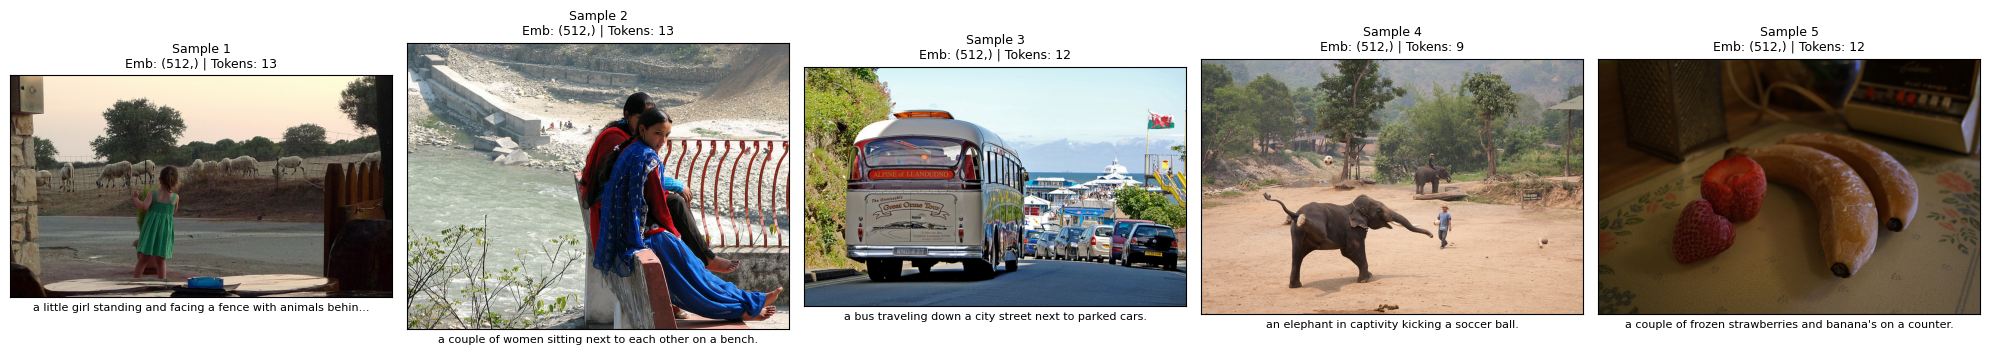

Saved → sample_test_runs.png


In [12]:
# Visual grid of all 5 samples
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(4 * N_SAMPLES, 5))

for ax, res in zip(axes, results):
    ax.imshow(res["image"])
    ax.set_title(
        f"Sample {res['index']}\n"
        f"Emb: {res['embedding_shape']} | Tokens: {res['token_count']}",
        fontsize=9,
    )
    cap_display = res["caption"][:60] + ("..." if len(res["caption"]) > 60 else "")
    ax.set_xlabel(cap_display, fontsize=8, wrap=True)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("sample_test_runs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → sample_test_runs.png")

---
## 5. Summary

| Deliverable | Status |
|-------------|--------|
| Dataset chosen (COCO Captions) and preprocessed (2,500 pairs) | ✅ |
| Environment set up (PyTorch + HuggingFace Transformers + CLIP) | ✅ |
| Baseline notebook: image → embedding pipeline | ✅ |
| Caption tokenization using GPT-2 tokenizer | ✅ |
| 5 sample image:caption test runs | ✅ |

**Next steps (Milestone 2):** Train the mapping network and fine-tune GPT-2 with LoRA on Google Colab GPU.